# Product Recommendation System
- Popularity-based recommender (orders + revenue + rating)
- User-based collaborative filtering (cosine similarity)
- Item-based collaborative filtering (cosine similarity)
- System evaluation (coverage, precision@K)
- Save models

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Data

In [2]:
transactions = pd.read_csv('../data/Transactions.csv')
products     = pd.read_csv('../data/Products.csv')
customers    = pd.read_csv('../data/Customers.csv')

print(f"Transactions : {transactions.shape}")
print(f"Products     : {products.shape}")
print(f"Customers    : {customers.shape}")
print()
print("Products columns:", list(products.columns))

Transactions : (55000, 11)
Products     : (500, 12)
Customers    : (5500, 23)

Products columns: ['product_id', 'product_name', 'brand', 'product_category', 'mrp', 'stock_quantity', 'seasonality_score', 'average_daily_sales', 'conversion_rate', 'rating', 'number_of_reviews', 'is_prime_eligible']


## 3. Popularity-Based Recommender

In [3]:
product_stats = transactions.groupby('product_id').agg(
    total_orders   = ('transaction_id', 'count'),
    total_revenue  = ('total_amount', 'sum'),
    total_quantity = ('quantity', 'sum')
).reset_index()

product_stats = product_stats.merge(
    products[['product_id','product_name','product_category','mrp','rating','number_of_reviews']],
    on='product_id', how='left'
)

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

product_stats['popularity_score'] = (
    0.40 * normalize(product_stats['total_orders']) +
    0.35 * normalize(product_stats['total_revenue']) +
    0.25 * normalize(product_stats['rating'])
)

top_products = product_stats.sort_values('popularity_score', ascending=False).reset_index(drop=True)
print("Top 10 Popular Products:")
print(top_products[['product_name','product_category','total_orders','rating','popularity_score']].head(10).to_string(index=False))

Top 10 Popular Products:
                        product_name product_category  total_orders  rating  popularity_score
              HP Spectre Fold Laptop      Electronics            69     4.8          0.600675
                 Canon EOS R3 Camera      Electronics            61     4.9          0.594508
         Apple MacBook Pro 16 M3 Max      Electronics            72     4.9          0.560000
        Maybelline Fit Me Foundation           Beauty           455     4.6          0.553539
        Minimalist Niacinamide Serum           Beauty           452     4.6          0.550617
Harry Potter Chamber of Secrets Book            Books           348     4.9          0.546029
           Maybelline Colossal Kajal           Beauty           445     4.6          0.542531
     Dove Beauty Cream Bar Soap Pack           Beauty           440     4.6          0.537851
       Loreal Paris Revitalift Serum           Beauty           428     4.6          0.529739
          Neutrogena Sunscreen SPF5

In [4]:
def recommend_popular(category=None, top_n=5):
    pool = top_products.copy()
    if category:
        pool = pool[pool['product_category'] == category]
    return pool.head(top_n)[['product_id','product_name','product_category','mrp','rating','popularity_score']]

# Demo
print("Overall Top 5:")
print(recommend_popular(top_n=5).to_string(index=False))
print()
print("Top 5 in Electronics:")
print(recommend_popular(category='Electronics', top_n=5).to_string(index=False))

Overall Top 5:
product_id                 product_name product_category    mrp  rating  popularity_score
     P1268       HP Spectre Fold Laptop      Electronics 499999     4.8          0.600675
     P1270          Canon EOS R3 Camera      Electronics 499999     4.9          0.594508
     P1152  Apple MacBook Pro 16 M3 Max      Electronics 349900     4.9          0.560000
     P1332 Maybelline Fit Me Foundation           Beauty    599     4.6          0.553539
     P1337 Minimalist Niacinamide Serum           Beauty    599     4.6          0.550617

Top 5 in Electronics:
product_id                product_name product_category    mrp  rating  popularity_score
     P1268      HP Spectre Fold Laptop      Electronics 499999     4.8          0.600675
     P1270         Canon EOS R3 Camera      Electronics 499999     4.9          0.594508
     P1152 Apple MacBook Pro 16 M3 Max      Electronics 349900     4.9          0.560000
     P1178      Canon RF 70-200mm Lens      Electronics 229999    

## 4. Visualise Popular Products

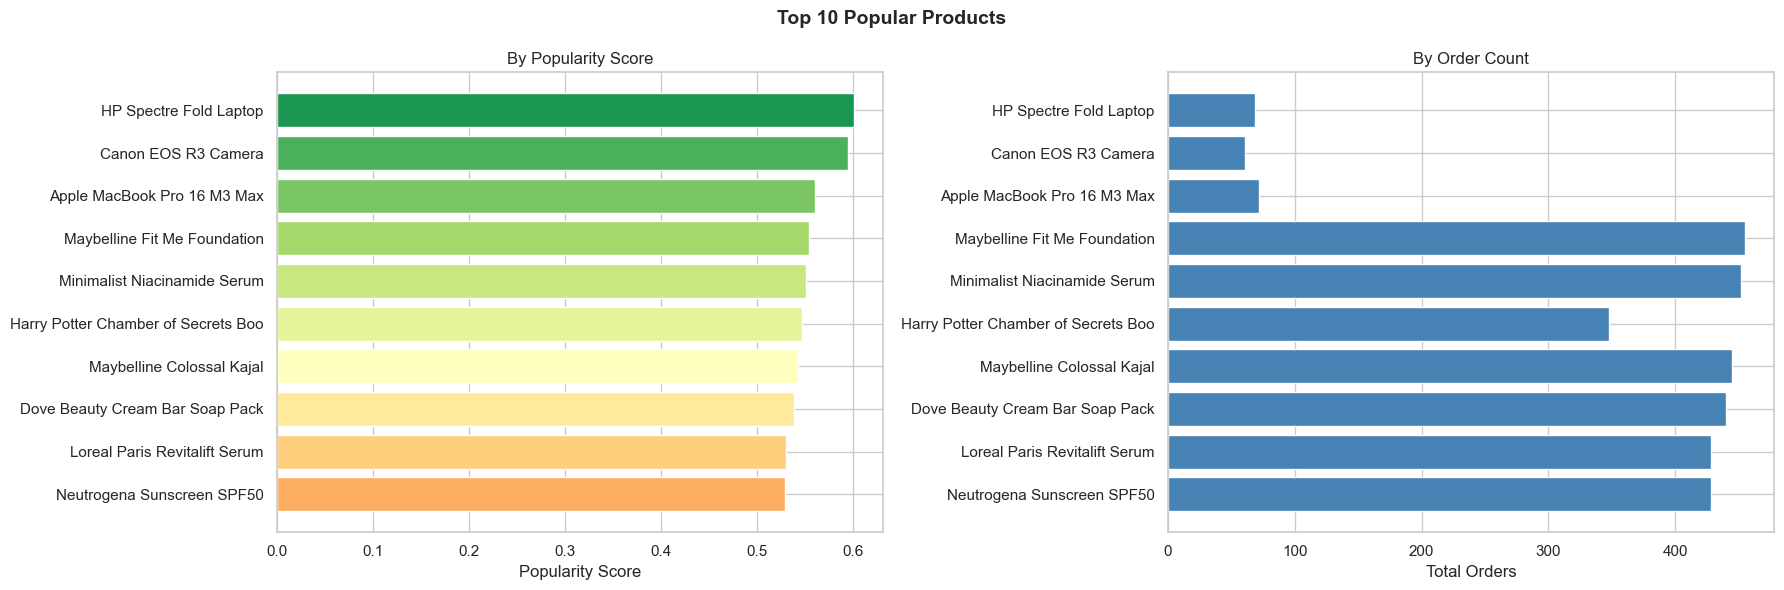

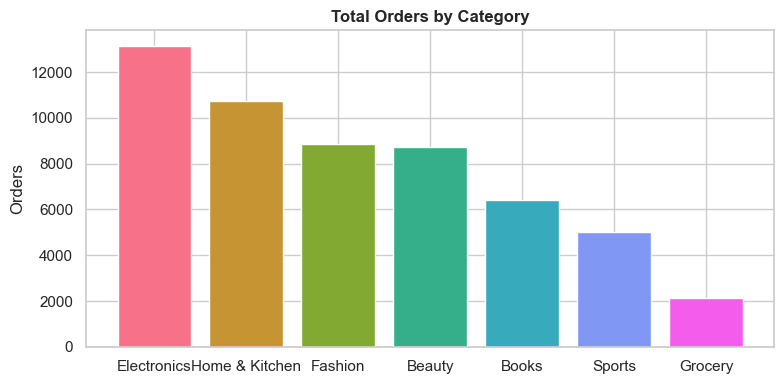

In [5]:
top10 = top_products.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Top 10 Popular Products', fontsize=14, fontweight='bold')

# Popularity score
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))
axes[0].barh(top10['product_name'].str[:35][::-1], top10['popularity_score'][::-1], color=colors)
axes[0].set_xlabel('Popularity Score')
axes[0].set_title('By Popularity Score')

# Total orders
axes[1].barh(top10['product_name'].str[:35][::-1], top10['total_orders'][::-1], color='steelblue')
axes[1].set_xlabel('Total Orders')
axes[1].set_title('By Order Count')

plt.tight_layout()
plt.savefig('../output/rec_popular_products.png', dpi=150, bbox_inches='tight')
plt.show()

# Category popularity heatmap
cat_product_orders = transactions.groupby(['category','product_id'])['transaction_id'].count().reset_index()
cat_product_orders.columns = ['category','product_id','orders']
cat_summary = cat_product_orders.groupby('category')['orders'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_summary.index, cat_summary.values, color=sns.color_palette('husl', len(cat_summary)))
ax.set_title('Total Orders by Category', fontweight='bold')
ax.set_ylabel('Orders')
plt.tight_layout()
plt.savefig('../output/rec_category_orders.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Build User-Item Matrix

In [6]:
active_customers = (transactions.groupby('customer_id')['transaction_id']
                    .count()
                    .loc[lambda x: x >= 2]
                    .index)

txn_active = transactions[transactions['customer_id'].isin(active_customers)]

user_item = (txn_active
    .groupby(['customer_id','product_id'])['quantity']
    .sum()
    .unstack(fill_value=0))

print(f"User-Item Matrix shape: {user_item.shape}")
print(f"Active customers: {user_item.shape[0]:,}")
print(f"Products covered: {user_item.shape[1]:,}")
print(f"Matrix sparsity : {(user_item == 0).sum().sum() / user_item.size * 100:.1f}%")

User-Item Matrix shape: (5498, 500)
Active customers: 5,498
Products covered: 500
Matrix sparsity : 98.1%


## 6. User-Based Collaborative Filtering

In [7]:
# cosine similarity
user_sim_matrix = cosine_similarity(user_item.values)
user_sim_df = pd.DataFrame(user_sim_matrix,
                            index=user_item.index,
                            columns=user_item.index)

print(f"User similarity matrix: {user_sim_df.shape}")

def recommend_for_user(customer_id, top_n=5, n_similar_users=10):
    if customer_id not in user_sim_df.index:
        print(f"Customer {customer_id} not in model. Returning popular items.")
        return recommend_popular(top_n=top_n)
    
    similar_users = user_sim_df[customer_id].drop(customer_id).nlargest(n_similar_users).index
    similar_purchases = user_item.loc[similar_users].sum(axis=0)
    
    already_bought = user_item.loc[customer_id]
    not_bought = already_bought[already_bought == 0].index
    
    recs = similar_purchases[not_bought].nlargest(top_n).reset_index()
    recs.columns = ['product_id','score']
    recs = recs.merge(products[['product_id','product_name','product_category','mrp','rating']],
                      on='product_id', how='left')
    return recs

# Demo
sample_customer = user_item.index[0]
print(f"\nRecommendations for {sample_customer}:")
print(recommend_for_user(sample_customer).to_string(index=False))

User similarity matrix: (5498, 5498)

Recommendations for C00001:
product_id  score                    product_name product_category  mrp  rating
     P1411      9 Prestige Induction Base Fry Pan   Home & Kitchen 1299     4.5
     P1045      6   Puma Flyer Flex Running Shoes          Fashion 3999     4.4
     P1387      6     Generic Foam Roller Massage           Sports  899     4.4
     P1064      5        Nike Gym Club Duffel Bag          Fashion 2995     4.5
     P1185      5              Puma RS-X Sneakers          Fashion 7999     4.4


## 7. User Similarity Visualisation

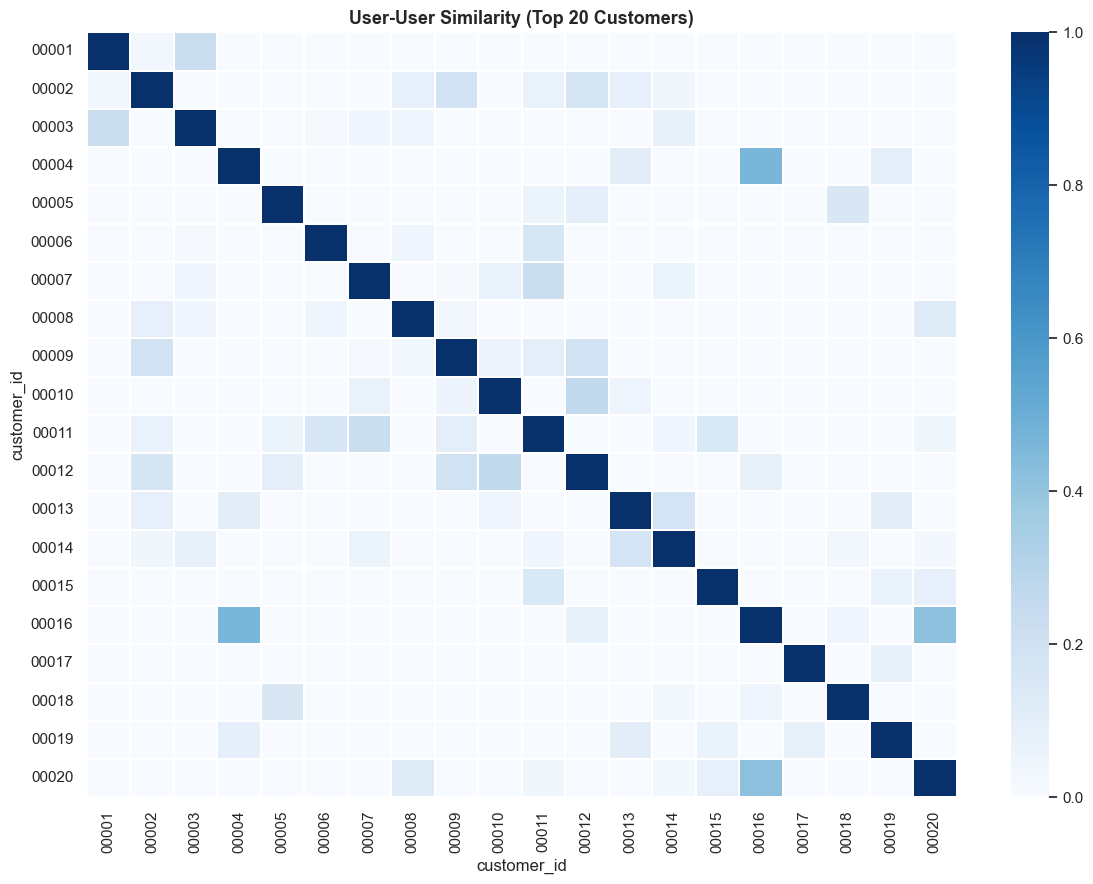

In [8]:
sample_users = user_item.index[:20]
sim_subset = user_sim_df.loc[sample_users, sample_users]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(sim_subset, cmap='Blues', ax=ax, linewidths=0.3,
            xticklabels=[u[-5:] for u in sample_users],
            yticklabels=[u[-5:] for u in sample_users])
ax.set_title('User-User Similarity (Top 20 Customers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/rec_user_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Item-Based Collaborative Filtering

In [9]:
item_sim_matrix = cosine_similarity(user_item.T.values)
item_sim_df = pd.DataFrame(item_sim_matrix,
                            index=user_item.columns,
                            columns=user_item.columns)

print(f"Item similarity matrix: {item_sim_df.shape}")

def recommend_similar_items(product_id, top_n=5):
    if product_id not in item_sim_df.index:
        print(f"Product {product_id} not in model.")
        return None
    
    sim_scores = item_sim_df[product_id].drop(product_id).nlargest(top_n).reset_index()
    sim_scores.columns = ['product_id','similarity']
    sim_scores = sim_scores.merge(
        products[['product_id','product_name','product_category','mrp','rating']],
        on='product_id', how='left')
    return sim_scores

# Demo
sample_product = user_item.columns[0]
prod_name = products.loc[products['product_id']==sample_product,'product_name'].values
print(f"\nItems similar to {sample_product} ({prod_name[0] if len(prod_name) else 'N/A'}):")
print(recommend_similar_items(sample_product).to_string(index=False))

Item similarity matrix: (500, 500)

Items similar to P1001 (Apple iPhone 17 Pro):
product_id  similarity                  product_name product_category    mrp  rating
     P1144    0.072458       HP Reverb G2 VR Headset      Electronics  69999     4.5
     P1258    0.065214       Canon RF 16mm f2.8 Lens      Electronics  32999     4.7
     P1270    0.063092           Canon EOS R3 Camera      Electronics 499999     4.9
     P1269    0.057090            Lenovo Tab Extreme      Electronics  89999     4.6
     P1427    0.056211 Nike Everyday Cushioned Socks          Fashion    999     4.4


## 9. Recommendation System Evaluation

Catalog Coverage : 100.0%  (500/500 products)

Item Similarity Stats:
  Mean   : 0.0140
  Median : 0.0090
  Max    : 0.2171


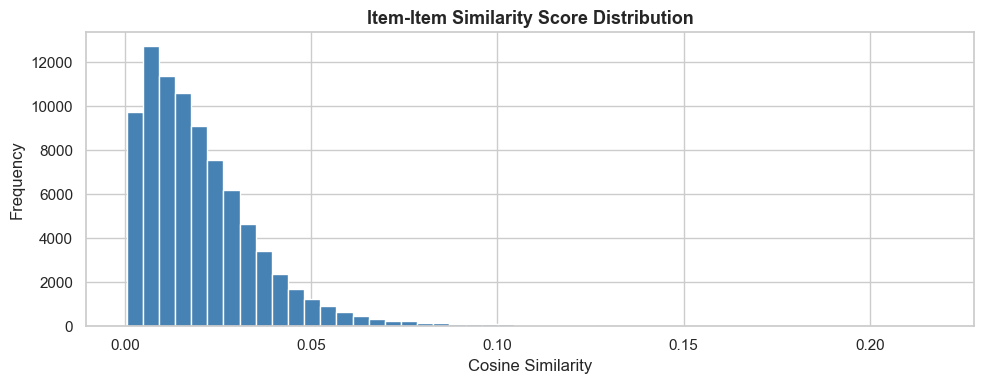

In [10]:
all_catalog = set(products['product_id'])
recommendable = set(user_item.columns)
coverage = len(recommendable) / len(all_catalog) * 100
print(f"Catalog Coverage : {coverage:.1f}%  ({len(recommendable)}/{len(all_catalog)} products)")

all_sims = item_sim_df.values[np.triu_indices_from(item_sim_df.values, k=1)]
print(f"\nItem Similarity Stats:")
print(f"  Mean   : {all_sims.mean():.4f}")
print(f"  Median : {np.median(all_sims):.4f}")
print(f"  Max    : {all_sims.max():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_sims[all_sims > 0], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Item-Item Similarity Score Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../output/rec_item_sim_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Models

In [11]:
with open('../models/product_popularity.pkl', 'wb') as f:
    pickle.dump(top_products, f)

with open('../models/user_item_matrix.pkl', 'wb') as f:
    pickle.dump(user_item, f)

with open('../models/user_similarity.pkl', 'wb') as f:
    pickle.dump(user_sim_df, f)

with open('../models/item_similarity.pkl', 'wb') as f:
    pickle.dump(item_sim_df, f)

print("Saved:")
print("   models/product_popularity.pkl")
print("   models/user_item_matrix.pkl")
print("   models/user_similarity.pkl")
print("   models/item_similarity.pkl")

Saved:
   models/product_popularity.pkl
   models/user_item_matrix.pkl
   models/user_similarity.pkl
   models/item_similarity.pkl
